## Problem Definition

We are addressing an **image classification problem** with four distinct categories: *budgie*, *rubber duck*, *canary*, and *duckling*. The dataset consists of both **labeled** and **unlabeled images**. While the labeled data offers ground truth for model training, a significant portion of the dataset remains unlabeled, adding complexity to the task.

The objective is to develop a model that can leverage both the labeled and unlabeled data to enhance performance. The challenge lies in effectively utilizing the unlabeled data to improve classification accuracy and robustness.

### Requirements:
- The model must be implemented using **`torch`** and **`torchvision`** only (no other deep learning libraries are allowed for the model architecture).
- The main class for the model must be named <font color='red'>**`Model`**</font>, and participants <font color='red'>**must not change this name**</font>.
- Do not change the init function inside the **`Model`** class.
- The size of your model should not exceed 70 MB.
- Instantiating your model must not require any parameters.


In [1]:
# from datasets import load_dataset
from torch.utils.data import Dataset,DataLoader
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from torchvision import transforms, models
import os
import sys
from huggingface_hub import snapshot_download
from PIL import Image
from typing import Tuple, List
import random

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [3]:
dataset_id = "RayanAi/Noisy_birds"
# Set the local directory where you want to store the dataset
local_dataset_dir = "./Noisy_birds"  # You can change this path to your desired location

# Create the directory if it doesn't exist
os.makedirs(local_dataset_dir, exist_ok=True)

# Suppress the output by redirecting it to os.devnull
with open(os.devnull, 'w') as fnull:
    # Save the original stdout
    original_stdout = sys.stdout
    try:
        # Redirect stdout to devnull to suppress output
        sys.stdout = fnull
        # Download the dataset and store it locally
        snapshot_download(repo_id=dataset_id, local_dir=local_dataset_dir, repo_type="dataset")
    finally:
        # Restore the original stdout
        sys.stdout = original_stdout

# Print message when download is complete
print("Dataset downloaded completely.")

# Calculate and print the total size of the downloaded files
total_size = 0
for dirpath, dirnames, filenames in os.walk(local_dataset_dir):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

# Convert size to MB and print
print(f"Total size of downloaded files: {total_size / (1024 * 1024):.2f} MB")

# Get the absolute path of the dataset directory and print it
dataset_abs_path = os.path.abspath(local_dataset_dir)
print(f"Dataset has been saved at: [{dataset_abs_path}]")


/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Noisy_birds.zip:   0%|          | 0.00/7.98M [00:00<?, ?B/s]

.gitattributes:   0%|          | 0.00/2.42k [00:00<?, ?B/s]

Dataset downloaded completely.
Total size of downloaded files: 7.61 MB
Dataset has been saved at: [/content/Noisy_birds]


In [4]:
!unzip -qo ./Noisy_birds/Noisy_birds.zip -d ./Noisy_birds/

## Dataset

In this part, the dataset is downloaded and needed agumentation functions are applied. You only need to define the necessary transform functions for augmentation. At the end you are provided with a train_loader, val_loader and a test_loader.

In [5]:
class Model(nn.Module):
    def __init__(self, base_encoder, projection_dim=64):
        super(Model, self).__init__()
        self.encoder = base_encoder
        self.projection_head = nn.Sequential(
            nn.Linear(1000, 512),  # Adjust based on ResNet version
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        features = self.encoder(x)
        projections = self.projection_head(features)
        return F.normalize(projections, dim=1)  # Normalize the projections


In [6]:
# Contrastive Loss (NT-Xent)
class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        z = torch.cat([z_i, z_j], dim=0)
        sim_matrix = torch.mm(z, z.t()) / self.temperature

        labels = torch.cat([torch.arange(batch_size) for _ in range(2)], dim=0)
        labels = (labels.unsqueeze(0) == labels.unsqueeze(1)).float()
        labels = labels.to(device)

        sim_matrix = sim_matrix - torch.eye(2 * batch_size).to(z.device) * 1e-9
        sim_matrix = F.log_softmax(sim_matrix, dim=-1)

        loss = -torch.mean(torch.sum(labels * sim_matrix, dim=-1))
        return loss

In [7]:
# Data Augmentation
transform = transforms.Compose([
    transforms.RandomResizedCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor()
])

In [151]:
# Training loop
def train_simclr(model, dataloader, optimizer, criterion, scheduler, epochs=100):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for batch in dataloader:
            img1, img2 = batch
            img1, img2 = img1.to(device), img2.to(device)
            z_i = model(img1)
            z_j = model(img2)
            loss = criterion(z_i, z_j)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
        scheduler.step()
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(dataloader)}')
        print(f'LR:{scheduler.get_last_lr()}')


In [55]:
# Fine-tuning for Classification
class ClassificationModel(nn.Module):
    def __init__(self, encoder):
        super(ClassificationModel, self).__init__()
        self.encoder = encoder
        self.fc = nn.Sequential(nn.Linear(64, 32),
                                nn.ReLU(),
                                nn.Linear(32, 4))
        # self.fc = nn.Linear(64, 4)  # 4 bird classes
        # self.encoder.requires_grad=False

    def forward(self, x):
        features = self.encoder(x)
        return self.fc(features)

In [10]:
# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

# transform_test = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],
#                          std=[0.229, 0.224, 0.225])
# ])

In [11]:
class UnlabeledDataset(Dataset):

    def __init__(self, image_dir: str, allowed_classes: List, transform=None, dataset_type: str = None):
        """
        Args:
            image_dir (str): Directory path containing input images.
            mask_dir (str): Directory path containing corresponding segmentation masks.
            transform (callable): Optional transformation to be applied to both the image and the mask. . Use ToTensorV2()
            dataset_type (str, optional): Type of dataset, e.g., 'Train' or 'Test'. Defaults to 'Train'.
        """
        # Initialize paths and transformation
        self.allowed_classes=allowed_classes
        self.image_dir = image_dir
        self.dataset_type = dataset_type
        self.transform = transform
        self.classes = [item for item in os.listdir(self.image_dir) if os.path.isdir(os.path.join(self.image_dir, item))]
        self.samples=[]
        for class_name in self.classes:
                if class_name in allowed_classes:

                    self.images = os.listdir(os.path.join(self.image_dir, class_name))
                    for img in self.images:
                        self.samples.append([img,class_name])

        random.seed(87)
        random.shuffle(self.samples)
        self.images = self.samples

        self.transform = transform

    def __len__(self) -> int:
        """
        Returns:
            int: The total number of image-mask pairs in the designated dataset split.
        """
        # Return the length of the dataset (number of images)
        return len(self.images)


    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            index (int): Index of the image-mask pair to retrieve.

        Returns:
            Tuple[torch.Tensor, torch.Tensor]: A tuple containing the image and its corresponding one-hot encoded mask.
                - image (torch.Tensor): Transformed image tensor.
                - onehot_mask (torch.Tensor): One-hot encoded mask tensor for segmentation.
        """
        # Load the image and mask
        image_path = os.path.join(self.image_dir,self.images[index][1],self.images[index][0])



        # Load image and mask as grayscale
        image = Image.open(image_path)

        img1 = self.transform(image)  # First augmented view
        img2 = self.transform(image)  # Second augmented view
        return img1, img2








In [12]:
unlabeled_dataset = UnlabeledDataset(
    image_dir="./Noisy_birds",
    allowed_classes=["unlabeled"],
    transform=transform

)

In [13]:
# import os
# import numpy as np
# import random
# import torch
# import torch.nn.functional as F
# from torch.utils.data import Dataset
# #Define the split ratio
# split_ratio = 0.6

# #Dataset function called
# class Birddataset(Dataset):
#     def __init__(self, image_dir: str, allowed_classes: List, transform=None, dataset_type: str = None):
#         """
#         Args:
#             image_dir (str): Directory path containing input images.
#             mask_dir (str): Directory path containing corresponding segmentation masks.
#             transform (callable): Optional transformation to be applied to both the image and the mask. . Use ToTensorV2()
#             dataset_type (str, optional): Type of dataset, e.g., 'Train' or 'Test'. Defaults to 'Train'.
#         """
#         # Initialize paths and transformation
#         self.allowed_classes=allowed_classes
#         self.image_dir = image_dir
#         self.dataset_type = dataset_type
#         self.transform = transform
#         self.classes = [item for item in os.listdir(self.image_dir) if os.path.isdir(os.path.join(self.image_dir, item))]
#         self.samples=[]
#         for class_name in self.classes:
#                 if class_name in allowed_classes:

#                     self.images = os.listdir(os.path.join(self.image_dir, class_name))
#                     for img in self.images:
#                         self.samples.append([img,class_name])

#         random.seed(87)
#         random.shuffle(self.samples)

#         # print(self.samples)

#         if dataset_type == 'Train':
#             self.images = self.samples[:int(len(self.samples)*split_ratio)]
#         elif dataset_type == 'Test':
#             self.images = self.samples[int(len(self.samples)*split_ratio):]
#         else:
#             self.images = self.samples

#     def __len__(self) -> int:
#         """
#         Returns:
#             int: The total number of image-mask pairs in the designated dataset split.
#         """
#         # Return the length of the dataset (number of images)
#         return len(self.images)


#     def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
#         """
#         Args:
#             index (int): Index of the image-mask pair to retrieve.

#         Returns:
#             Tuple[torch.Tensor, torch.Tensor]: A tuple containing the image and its corresponding one-hot encoded mask.
#                 - image (torch.Tensor): Transformed image tensor.
#                 - onehot_mask (torch.Tensor): One-hot encoded mask tensor for segmentation.
#         """
#         # Load the image and mask
#         image_path = os.path.join(self.image_dir,self.images[index][1],self.images[index][0])



#         # Load image and mask as grayscale
#         image = Image.open(image_path)
#         if self.transform:
#             transformed = self.transform(image)
#         else:
#             transformed = transform_test(image)

#         class_id = self.allowed_classes.index(self.images[index][1])

#         return transformed, class_id



In [14]:
# train_dataset = Birddataset(
#     image_dir="./Noisy_birds",
#     allowed_classes=["budgie","canary","duckling","rubber duck"],
#     transform=transform,

#     dataset_type='Train',

# )

# val_dataset = Birddataset(
#     image_dir= "./Noisy_birds",
#     allowed_classes=["budgie","canary","duckling","rubber duck"],
#     # transform=transform_test,
#     dataset_type='Test',

# )

# unlabeled_dataset = Birddataset(
#     image_dir="./Noisy_birds",
#     allowed_classes=["unlabeled"],
#     transform=transform

# )

In [15]:
batch_size = 128
num_workers = 2 # Change if you have beefy CPU
# train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=num_workers)
# val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=num_workers)
unlabeled_loader = torch.utils.data.DataLoader(unlabeled_dataset, batch_size=batch_size, shuffle=False,num_workers=num_workers)

In [16]:
for img1, img2 in unlabeled_loader:
  print(img1.shape, img2.shape)
  break

torch.Size([128, 3, 128, 128]) torch.Size([128, 3, 128, 128])


## CNN
Define a CNN model. It should be small enough to require less than 2GB of Vram (GPU Memmory) when using a batch size of 128.

## Train

Here is the training functions. You should can use this function in the next part to train your model. It employes early stopping and returns the model and scores in the output.

In [146]:
base_encoder = models.densenet121(pretrained=True)
base_encoder.fc = nn.Identity()  # Remove the final classification layer for SimCLR
simclr_model = Model(base_encoder)



/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=DenseNet121_Weights.IMAGENET1K_V1`. You can also use `weights=DenseNet121_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [147]:
criterion = NTXentLoss(temperature=0.5)
optimizer = optim.Adam(simclr_model.parameters(), lr=4e-3)

In [148]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=15, gamma=0.25)

In [152]:
simclr_model = simclr_model.to(device)
train_simclr(simclr_model, unlabeled_loader, optimizer, criterion, scheduler, epochs=100)

Epoch [1/100], Loss: 9.970540237426757
LR:[0.004]
Epoch [2/100], Loss: 9.154601049423217
LR:[0.004]
Epoch [3/100], Loss: 8.831925535202027
LR:[0.004]
Epoch [4/100], Loss: 8.722543907165527
LR:[0.004]
Epoch [5/100], Loss: 8.649549293518067
LR:[0.004]
Epoch [6/100], Loss: 8.630651044845582
LR:[0.004]
Epoch [7/100], Loss: 8.538838863372803
LR:[0.004]
Epoch [8/100], Loss: 8.522646045684814
LR:[0.004]
Epoch [9/100], Loss: 8.44774842262268
LR:[0.004]
Epoch [10/100], Loss: 8.456425189971924
LR:[0.004]
Epoch [11/100], Loss: 8.45090560913086
LR:[0.004]
Epoch [12/100], Loss: 8.358203983306884
LR:[0.004]
Epoch [13/100], Loss: 8.392299938201905
LR:[0.004]
Epoch [14/100], Loss: 8.333633708953858
LR:[0.004]
Epoch [15/100], Loss: 8.328237295150757
LR:[0.001]
Epoch [16/100], Loss: 8.263855123519898
LR:[0.001]
Epoch [17/100], Loss: 8.217906713485718
LR:[0.001]
Epoch [18/100], Loss: 8.178700685501099
LR:[0.001]
Epoch [19/100], Loss: 8.174581575393677
LR:[0.001]
Epoch [20/100], Loss: 8.186995697021484
LR

In [153]:
torch.save(simclr_model.state_dict(), '/content/simclr_model.pth')

print("Model saved to /content/simclr_model.pth")

Model saved to /content/simclr_model.pth


In [154]:
import os
import numpy as np
import random
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
#Define the split ratio
split_ratio = 0.6

#Dataset function called
class Birddataset(Dataset):
    def __init__(self, image_dir: str, allowed_classes: List, transform=None, dataset_type: str = None):
        """
        Args:
            image_dir (str): Directory path containing input images.
            mask_dir (str): Directory path containing corresponding segmentation masks.
            transform (callable): Optional transformation to be applied to both the image and the mask. . Use ToTensorV2()
            dataset_type (str, optional): Type of dataset, e.g., 'Train' or 'Test'. Defaults to 'Train'.
        """
        # Initialize paths and transformation
        self.allowed_classes=allowed_classes
        self.image_dir = image_dir
        self.dataset_type = dataset_type
        self.transform = transform
        self.classes = [item for item in os.listdir(self.image_dir) if os.path.isdir(os.path.join(self.image_dir, item))]
        self.samples=[]
        for class_name in self.classes:
                if class_name in allowed_classes:

                    self.images = os.listdir(os.path.join(self.image_dir, class_name))
                    for img in self.images:
                        self.samples.append([img,class_name])

        random.seed(87)
        random.shuffle(self.samples)

        # print(self.samples)

        if dataset_type == 'Train':
            self.images = self.samples[:int(len(self.samples)*split_ratio)]
        elif dataset_type == 'Test':
            self.images = self.samples[int(len(self.samples)*split_ratio):]
        else:
            self.images = self.samples

    def __len__(self) -> int:
        """
        Returns:
            int: The total number of image-mask pairs in the designated dataset split.
        """
        # Return the length of the dataset (number of images)
        return len(self.images)


    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
            index (int): Index of the image-mask pair to retrieve.

        Returns:
            Tuple[torch.Tensor, torch.Tensor]: A tuple containing the image and its corresponding one-hot encoded mask.
                - image (torch.Tensor): Transformed image tensor.
                - onehot_mask (torch.Tensor): One-hot encoded mask tensor for segmentation.
        """
        # Load the image and mask
        image_path = os.path.join(self.image_dir,self.images[index][1],self.images[index][0])



        # Load image and mask as grayscale
        image = Image.open(image_path)
        if self.transform:
            transformed = self.transform(image)
        else:
            transformed = transform_test(image)

        class_id = self.allowed_classes.index(self.images[index][1])

        return transformed, class_id



In [155]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(128),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [156]:
train_dataset = Birddataset(
    image_dir="./Noisy_birds",
    allowed_classes=["budgie","canary","duckling","rubber duck"],
    transform=transform,

    dataset_type='Train',

)

val_dataset = Birddataset(
    image_dir= "./Noisy_birds",
    allowed_classes=["budgie","canary","duckling","rubber duck"],
    # transform=transform_test,
    dataset_type='Test',

)



In [157]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,num_workers=num_workers)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False,num_workers=num_workers)

In [172]:
simclr = Model(base_encoder)
  # Replace with your actual model class

# Load the saved state_dict
simclr.load_state_dict(torch.load('/content/simclr_model.pth'))

# Put the model in evaluation mode
# simclr.eval()

print("Model loaded from /content/simclr_model.pth")

Model loaded from /content/simclr_model.pth


<ipython-input-172-9e22dd09887f>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  simclr.load_state_dict(torch.load('/content/simclr_model.pth'))


In [173]:
model = ClassificationModel(simclr)
model = model.to(device)

In [174]:
model.encoder.requires_grad=False

In [175]:
optimizer = torch.optim.Adam(model.parameters(), lr=4e-3)
criterion = nn.CrossEntropyLoss()

In [176]:
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.25)

In [163]:
from tqdm import tqdm
def train(model: nn.Module, dataloader: DataLoader, num_epochs: int = 30,patience: int = 30, lr: float = 0.001) -> Tuple[nn.Module, List[List[float]]]:
    """
    Function to train the model.

    Input:
        model: The CNN model to be trained.
        dataloader: The DataLoader that provides the training and validation data.
        num_epochs: Number of epochs to train the model for (default is 30).
        lr: The learning rate (default is 0.001).

    Output:
        model: Best version of the trained model.
        scores: A list containing two lists: [training_losses, validation_losses].
    """

    scores = [[], []]



    best_val_loss = float('inf')  # Initialize with a large value
    best_model_state = None
    counter = 0  # Counter for early stopping

    for epoch in range(num_epochs):
        running_loss = 0.0
        model.train()  # Ensure the model is in training mode

        for (inputs, labels) in tqdm(dataloader):
            inputs, labels = inputs.to(device), labels.to(device)
            # Zero the parameter gradients
            optimizer.zero_grad()

            # Forward pass
            outputs = model(inputs)

            loss = criterion(outputs, labels)

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            # Accumulate training loss
            running_loss += loss.item() * len(inputs)

        # Calculate average training loss for the epoch
        avg_train_loss = running_loss
        scores[0].append(avg_train_loss)

        # Evaluation
        model.eval()  # Set model to evaluation mode
        running_val_loss = 0.0
        all_preds = []
        all_labels = []

        with torch.no_grad():  # No need to track gradients for validation
            for inputs, labels in val_loader:  # Using the global val_loader

                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                _, predicted = torch.max(outputs, 1)
                running_val_loss += loss.item() * len(inputs)
                # Store predictions and true labels
                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

        # Calculate average validation loss for the epoch
        avg_val_loss = running_val_loss
        scores[1].append(avg_val_loss)
        scheduler.step()
        print(f'Epoch {epoch+1}/{num_epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_val_loss:.4f}')
        print(f'LR: {scheduler.get_last_lr()}')

        # Check if this is the best model so far
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_model_state = model.state_dict()
            counter = 0  # Reset counter if the validation loss improves
        else:
            counter += 1  # Increment counter if the validation loss does not improve

        # Early stopping check
        if counter >= patience:
            print(f'Early stopping triggered after {epoch+1} epochs.')
            break

    # After training, load the best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print('Best model loaded based on validation loss.')

    all_preds = []
    all_labels = []
    with torch.no_grad():  # No need to track gradients for validation
        running_loss = 0.0
        for inputs, labels in val_loader:  # Using the global test_loader
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, predicted = torch.max(outputs, 1)

            # Store predictions and true labels
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Calculate F1 Score
    accuracy_counter=0
    for pred, label in zip(all_preds, all_labels):
        if pred == label:
            accuracy_counter+=1
    f1 = f1_score(all_labels, all_preds, average='weighted')  # Use 'micro' or 'macro' depending on your needs
    print(f'F1 Score on the Validation set: {f1:.4f}')
    print(f'Accuracy on the Validation set: {accuracy_counter/len(all_labels):.4f}')
    print(all_labels)
    print(all_preds)
    return model, scores


In [164]:
import matplotlib.pyplot as plt

def plot_losses(scores):
    """
    Plot the training and validation losses.

    Parameters:
    - scores: A list containing two lists [training_losses, validation_losses]
    """
    train_losses = scores[0]
    val_losses = scores[1]

    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Training Loss')
    plt.plot(val_losses, label='Validation Loss')
    plt.title('Training and Validation Losses')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()


Train your model.

100%|██████████| 1/1 [00:00<00:00,  1.49it/s]


Epoch 1/200, Training Loss: 126.2213, Validation Loss: 82.7836
LR: [0.004]


100%|██████████| 1/1 [00:00<00:00,  1.60it/s]


Epoch 2/200, Training Loss: 121.0335, Validation Loss: 84.2370
LR: [0.004]


100%|██████████| 1/1 [00:00<00:00,  1.65it/s]


...

Epoch 56/200, Training Loss: 73.8167, Validation Loss: 67.3657
LR: [0.00025]


100%|██████████| 1/1 [00:00<00:00,  1.63it/s]


Epoch 57/200, Training Loss: 75.0873, Validation Loss: 67.5716
LR: [0.00025]


100%|██████████| 1/1 [00:00<00:00,  1.64it/s]


Epoch 58/200, Training Loss: 73.1059, Validation Loss: 67.6536
LR: [0.00025]
Early stopping triggered after 58 epochs.
Best model loaded based on validation loss.
F1 Score on the Validation set: 0.4566
Accuracy on the Validation set: 0.5000
[0, 2, 1, 0, 0, 1, 2, 2, 1, 2, 1, 3, 0, 0, 2, 3, 3, 0, 1, 0, 2, 0, 3, 2, 0, 0, 3, 2, 2, 0, 3, 3, 0, 0, 2, 2, 0, 1, 0, 1, 2, 2, 2, 1, 3, 3, 1, 0, 2, 1, 0, 1, 0, 3, 0, 0, 1, 3, 2, 2]
[3, 2, 1, 1, 1, 1, 3, 2, 1, 3, 1, 3, 1, 3, 2, 3, 1, 3, 3, 1, 2, 1, 3, 2, 3, 1, 3, 3, 2, 1, 3, 2, 1, 0, 2, 3, 1, 1, 2, 3, 2, 2, 3, 1, 3, 2, 1, 3, 0, 1, 0, 3, 1, 3, 1, 1, 1, 3, 2, 2]


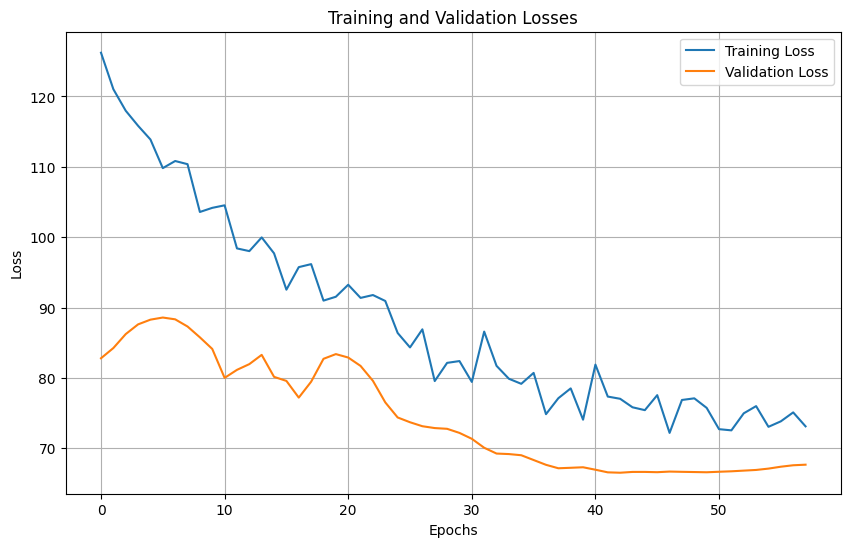

In [177]:
num_epochs=200
patience=15

model, training_scores = train(model,train_loader, num_epochs=num_epochs,patience = patience,lr = lr)
plot_losses(training_scores)

In [ ]:
model_save_path = "model.pth"
torch.save(model.state_dict(), model_save_path)